In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("✅ Libraries ready")

✅ Libraries ready


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [3]:
df = pd.read_csv('heart_disease_uci.csv')

df = df.rename(columns={
    'cp'       : 'chest_pain',
    'trestbps' : 'resting_bp',
    'chol'     : 'cholesterol',
    'fbs'      : 'fasting_bs',
    'restecg'  : 'resting_ecg',
    'thalch'   : 'max_hr',
    'exang'    : 'exercise_angina',
    'slope'    : 'st_slope',
    'num'      : 'target'
})

df.drop(columns=['id', 'dataset'], inplace=True)
df['target'] = (df['target'] > 0).astype(int)

print("Shape :", df.shape)
print("\nTarget:")
print(df['target'].value_counts())
df.head()

Shape : (920, 14)

Target:
target
1    509
0    411
Name: count, dtype: int64


,age,sex,chest_pain,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("Missing before:")
print(df.isnull().sum())

df.drop(columns=['ca', 'thal'], inplace=True)

# Numerical → median
for col in ['resting_bp', 'cholesterol', 'max_hr', 'oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → mode
for col in ['fasting_bs', 'resting_ecg', 'exercise_angina', 'st_slope']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing after:")
print(df.isnull().sum())
print("\nShape:", df.shape)

Missing before:
age                  0
sex                  0
chest_pain           0
resting_bp          59
cholesterol         30
fasting_bs          90
resting_ecg          2
max_hr              55
exercise_angina     55
oldpeak             62
st_slope           309
ca                 611
thal               486
target               0
dtype: int64

Missing after:
age                0
sex                0
chest_pain         0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
target             0
dtype: int64

Shape: (920, 12)


In [5]:
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

df['chest_pain'] = df['chest_pain'].map({
    'typical angina'  : 1,
    'atypical angina' : 2,
    'non-anginal'     : 3,
    'asymptomatic'    : 4
})

df['fasting_bs'] = df['fasting_bs'].map({True: 1, False: 0})

df['resting_ecg'] = df['resting_ecg'].map({
    'normal'           : 0,
    'st-t abnormality' : 1,
    'lv hypertrophy'   : 2
})

df['exercise_angina'] = df['exercise_angina'].map({True: 1, False: 0})

df['st_slope'] = df['st_slope'].map({
    'upsloping'   : 1,
    'flat'        : 2,
    'downsloping' : 3
})

# Fix any NaN from mapping
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("✅ Encoding done")
print(df.dtypes)

✅ Encoding done
age                  int64
sex                  int64
chest_pain           int64
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg          int64
max_hr             float64
exercise_angina      int64
oldpeak            float64
st_slope             int64
target               int64
dtype: object


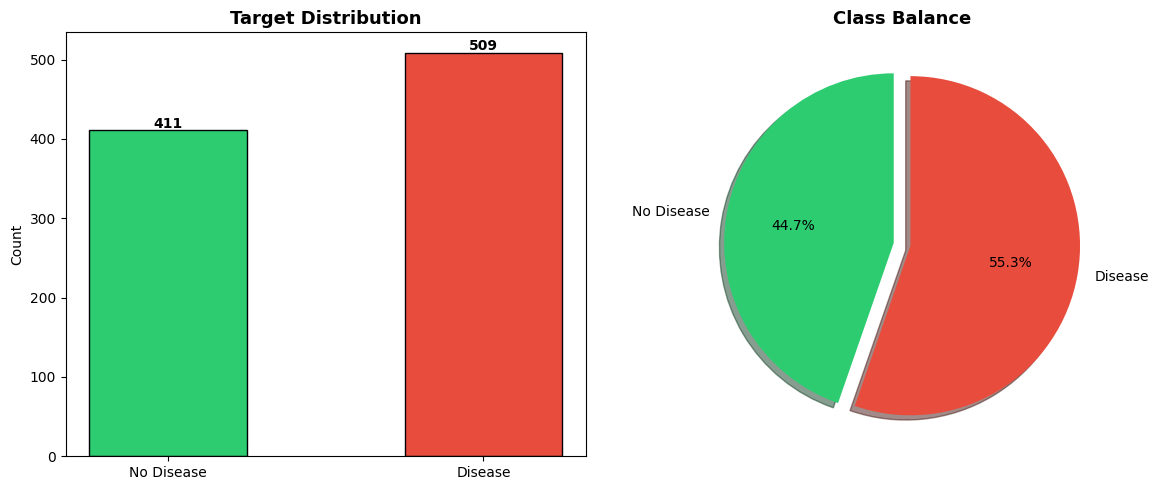

In [6]:
# Target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts().sort_index()
bars   = axes[0].bar(['No Disease', 'Disease'], counts,
                     color=['#2ecc71', '#e74c3c'],
                     edgecolor='black', width=0.5)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{int(bar.get_height())}',
                 ha='center', fontweight='bold')

axes[1].pie(counts, labels=['No Disease', 'Disease'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

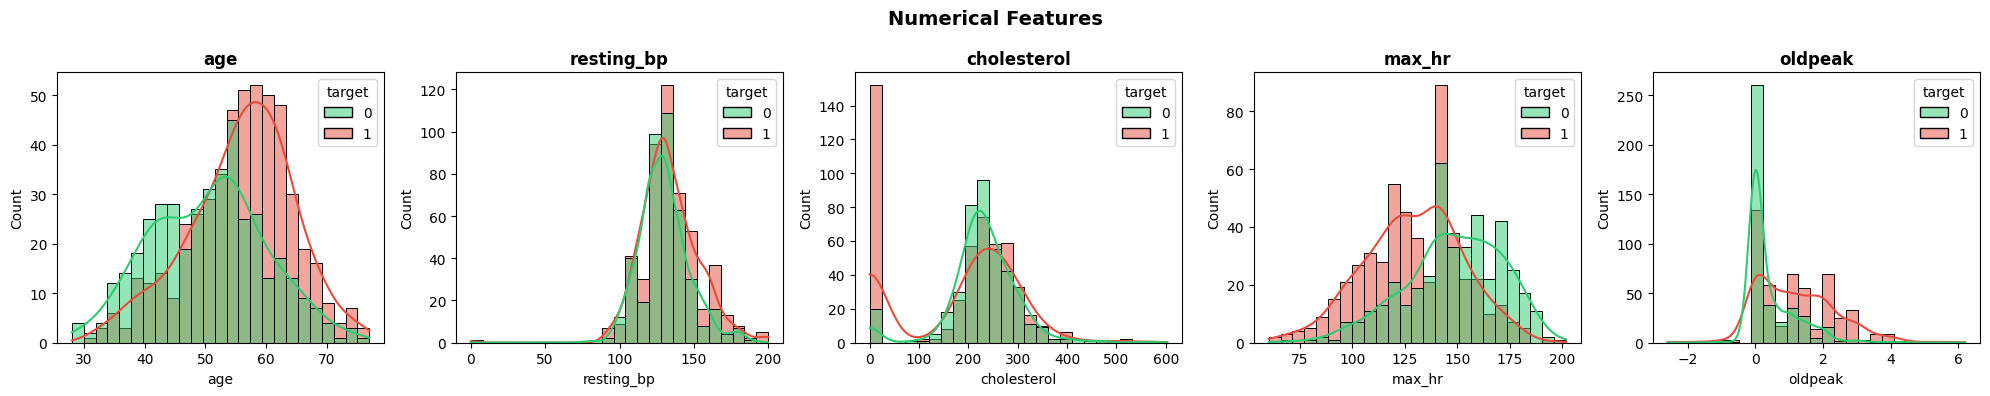

In [7]:
# Numerical distributions
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', bins=25,
                 kde=True, palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title(col, fontweight='bold')

plt.suptitle('Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

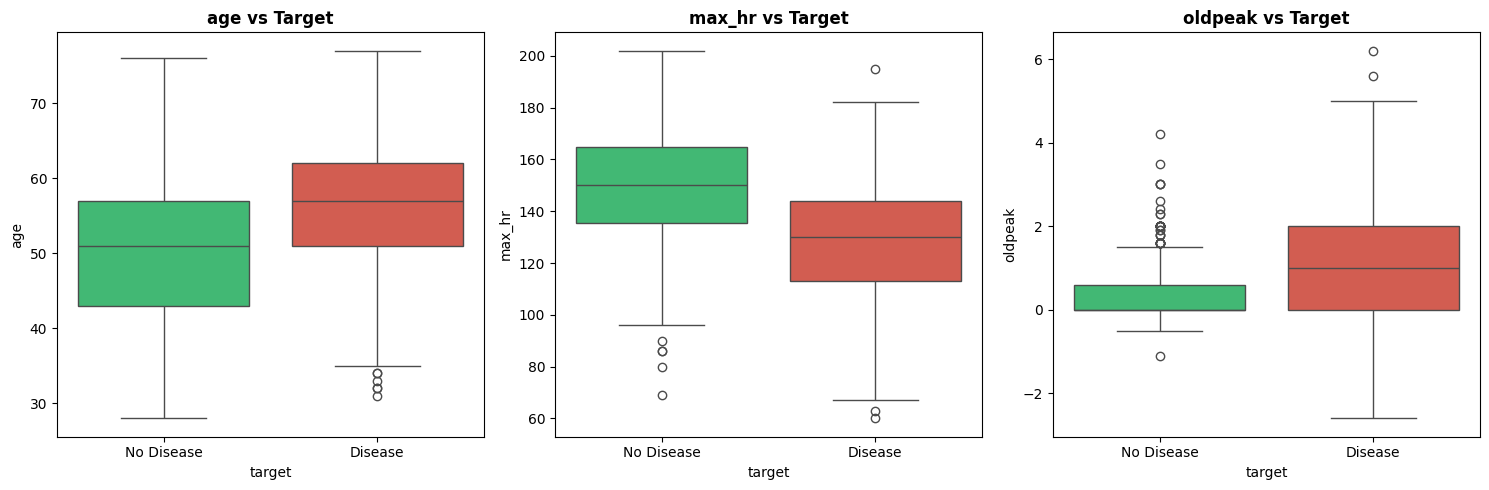

In [8]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['age', 'max_hr', 'oldpeak']):
    sns.boxplot(data=df, x='target', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['No Disease', 'Disease'])
    ax.set_title(f'{col} vs Target', fontweight='bold')

plt.tight_layout()
plt.show()

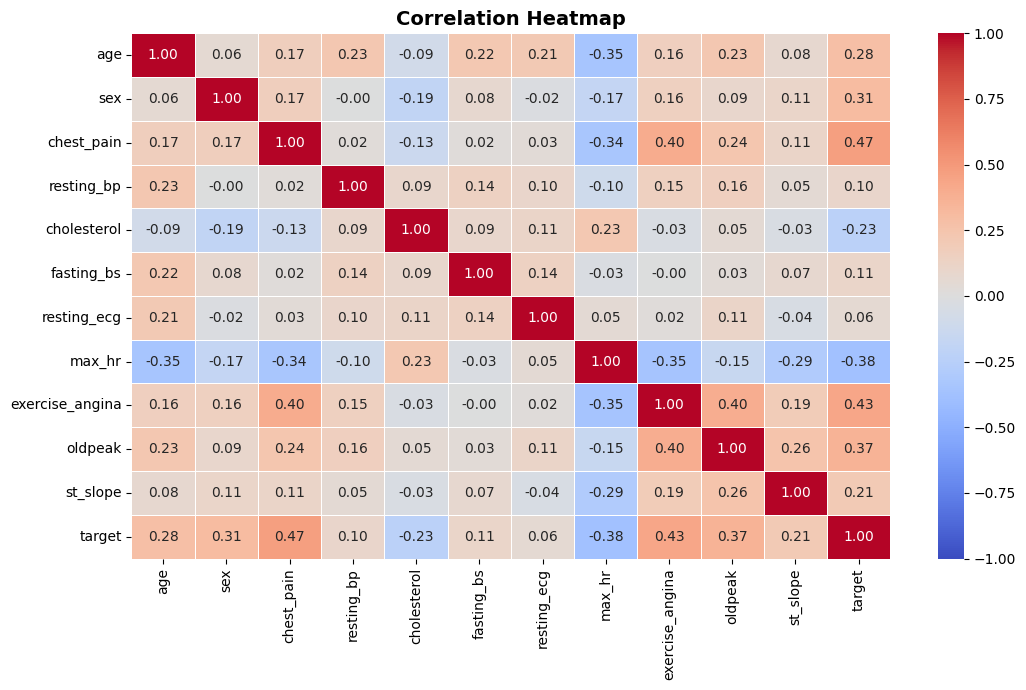

In [9]:
# Correlation
plt.figure(figsize=(11, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
df['age_group']    = pd.cut(df['age'],
                             bins=[0, 40, 50, 60, 100],
                             labels=[0, 1, 2, 3]).astype(int)

df['hr_age_ratio'] = (df['max_hr'] / df['age']).round(2)

df['hypertension'] = (df['resting_bp'] >= 140).astype(int)

df['chest_pain_severity'] = df['chest_pain'].map(
    {1: 0, 2: 1, 3: 2, 4: 3}
)

print("✅ Features engineered")
print("Shape:", df.shape)

✅ Features engineered
Shape: (920, 16)


In [11]:
X = df.drop('target', axis=1)
y = df['target']

feature_list = list(X.columns)

print("Features:")
for i, f in enumerate(feature_list, 1):
    print(f"  {i:02d}. {f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Features:
  01. age
  02. sex
  03. chest_pain
  04. resting_bp
  05. cholesterol
  06. fasting_bs
  07. resting_ecg
  08. max_hr
  09. exercise_angina
  10. oldpeak
  11. st_slope
  12. age_group
  13. hr_age_ratio
  14. hypertension
  15. chest_pain_severity

Train : 736
Test  : 184


In [12]:
models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter     = 2000,
                                C            = 0.5,
                                solver       = 'lbfgs',
                                random_state = 42),

    'Random Forest'       : RandomForestClassifier(
                                n_estimators      = 500,
                                max_depth         = 10,
                                min_samples_split = 4,
                                min_samples_leaf  = 2,
                                max_features      = 'sqrt',
                                random_state      = 42,
                                n_jobs            = -1),

    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators   = 500,
                                max_depth      = 4,
                                learning_rate  = 0.05,
                                subsample      = 0.8,
                                min_samples_split = 4,
                                random_state   = 42),
}

cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
trained = {}
results = []

for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    cv_acc = cross_val_score(model, Xtr, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    cv_auc = cross_val_score(model, Xtr, y_train,
                             cv=cv, scoring='roc_auc',  n_jobs=-1)

    model.fit(Xtr, y_train)
    trained[name] = model

    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model'       : name,
        'CV Accuracy' : round(cv_acc.mean(), 4),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'Accuracy'    : round(accuracy_score(y_test, y_pred),  4),
        'Precision'   : round(precision_score(y_test, y_pred), 4),
        'Recall'      : round(recall_score(y_test, y_pred),    4),
        'F1-Score'    : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'     : round(roc_auc_score(y_test, y_proba),  4),
    })

    print(f"✅ {name:<25} "
          f"Acc={round(accuracy_score(y_test,y_pred),4)}  "
          f"Recall={round(recall_score(y_test,y_pred),4)}  "
          f"AUC={round(roc_auc_score(y_test,y_proba),4)}")

results_df = (pd.DataFrame(results)
              .sort_values('Recall', ascending=False)
              .reset_index(drop=True))
print()
results_df

✅ Logistic Regression       Acc=0.7989  Recall=0.8431  AUC=0.8881
✅ Random Forest             Acc=0.8207  Recall=0.902  AUC=0.9061
✅ Gradient Boosting         Acc=0.8152  Recall=0.8627  AUC=0.8741



,Model,CV Accuracy,CV AUC,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.7950,0.8639,0.8207,0.8000,0.9020,0.8479,0.9061
1,Gradient Boosting,0.8031,0.8581,0.8152,0.8148,0.8627,0.8381,0.8741
2,Logistic Regression,0.8058,0.8703,0.7989,0.8037,0.8431,0.8230,0.8881


In [14]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("🔍 Tuning Gradient Boosting (Optimized Version)...")

# ── Smaller + smarter search space ─────────────────────
param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 4, 6],
}

# ── Cross Validation ───────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Search (FAST + CONTROLLED) ──────────────────
random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,              # 👈 مهم: بدل 243 تجربة → 20 بس
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2,              # 👈 يعطيك progress واضح
    random_state=42
)

# ── Train ──────────────────────────────────────────────
random_search.fit(X_train, y_train)

# ── Best Model ─────────────────────────────────────────
tuned_model = random_search.best_estimator_

print(f"\n✅ Best Params : {random_search.best_params_}")
print(f"   Best CV Recall : {random_search.best_score_:.4f}")

# ── Evaluation ─────────────────────────────────────────
y_pred  = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

print("\n── Tuned Model Performance ─────────────────")

print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision :", round(precision_score(y_test, y_pred), 4))
print("Recall    :", round(recall_score(y_test, y_pred), 4))
print("F1-Score  :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC   :", round(roc_auc_score(y_test, y_proba), 4))

🔍 Tuning Gradient Boosting (Optimized Version)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best Params : {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 6, 'max_depth': 5, 'learning_rate': 0.1}
   Best CV Recall : 0.8378

── Tuned Model Performance ─────────────────
Accuracy  : 0.8207
Precision : 0.8224
Recall    : 0.8627
F1-Score  : 0.8421
ROC-AUC   : 0.8803


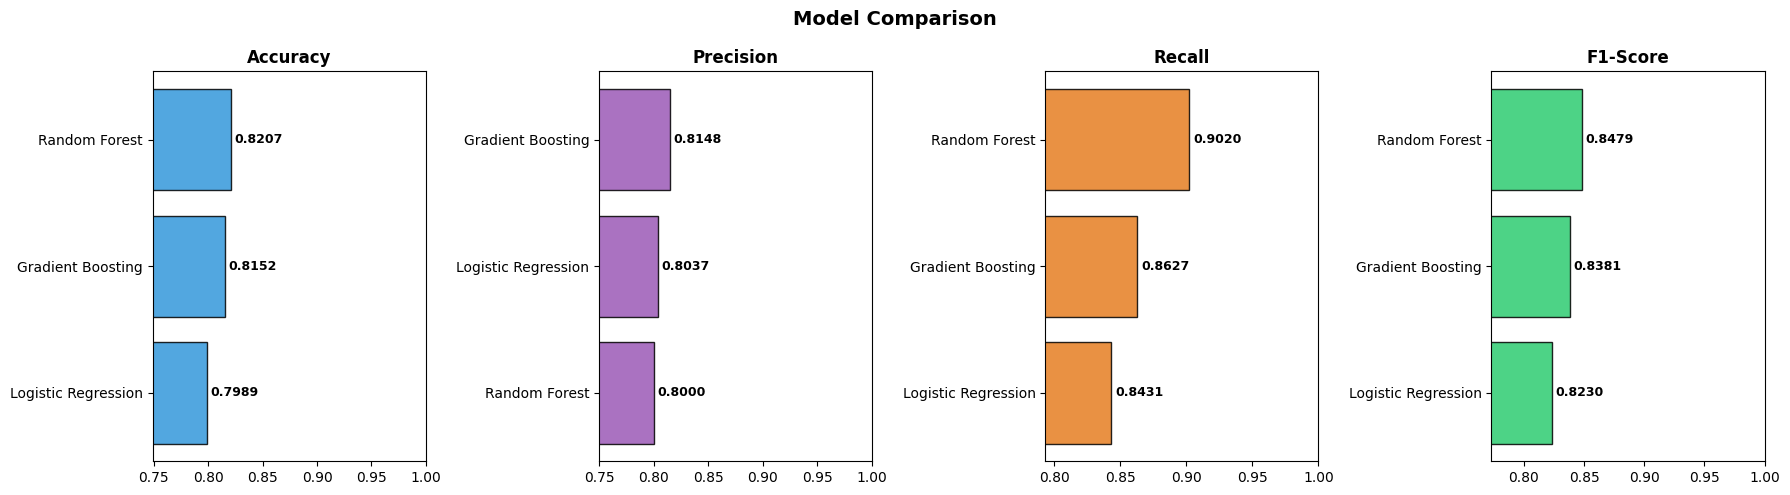

In [15]:
# Metrics
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, color in zip(
    axes,
    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    ['#3498db',  '#9b59b6',   '#e67e22', '#2ecc71']
):
    sdf  = results_df.sort_values(metric)
    bars = ax.barh(sdf['Model'], sdf[metric],
                   color=color, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(sdf[metric].min() - 0.05, 1.0)
    for bar in bars:
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}',
                va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

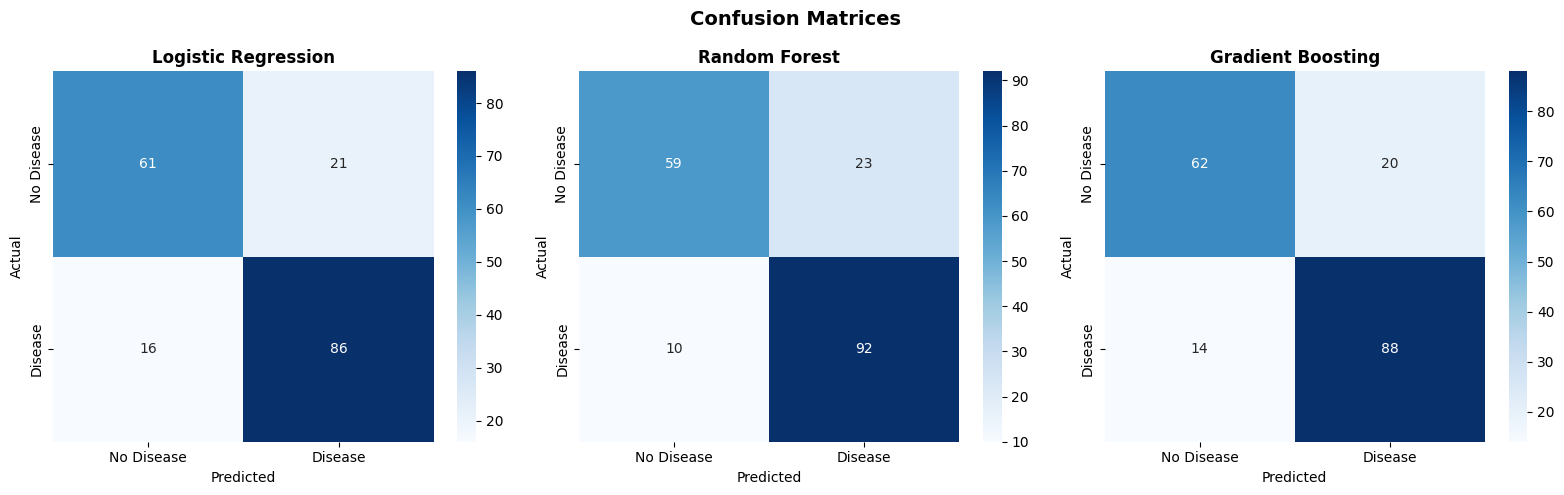

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, trained.items()):
    Xte    = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(Xte)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

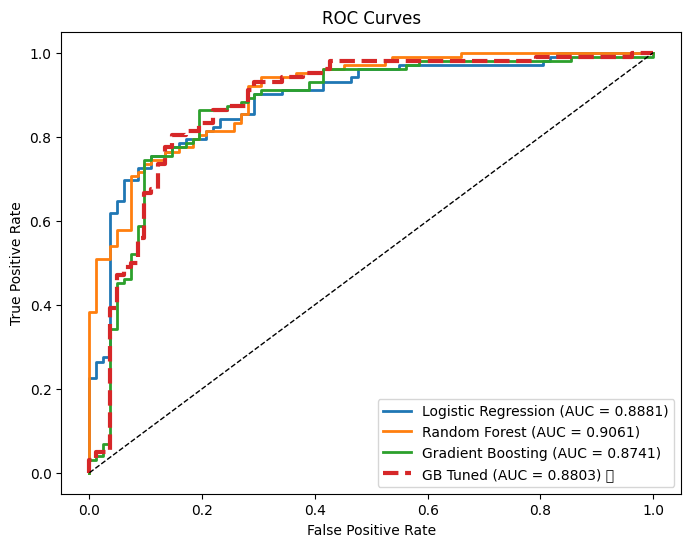

In [20]:
# Tuned model predictions (IMPORTANT)
y_pred_t  = tuned_model.predict(X_test)
y_proba_t = tuned_model.predict_proba(X_test)[:, 1]

# ROC Curves
plt.figure(figsize=(8, 6))

for name, model in trained.items():
    Xte = X_test_sc if name == 'Logistic Regression' else X_test
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)

    plt.plot(fpr, tpr, lw=2,
             label=f'{name} (AUC = {auc:.4f})')

# Tuned model
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_t)
auc_t = roc_auc_score(y_test, y_proba_t)

plt.plot(fpr_t, tpr_t, lw=3, linestyle='--',
         label=f'GB Tuned (AUC = {auc_t:.4f}) ⭐')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [21]:
# Classification Reports
for name, model in trained.items():
    Xte    = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(Xte)
    print(f"{'='*48}")
    print(f"  {name}")
    print(f"{'='*48}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease','Disease']))

print(f"{'='*48}")
print(f"  Gradient Boosting — Tuned ⭐")
print(f"{'='*48}")
print(classification_report(y_test, y_pred_t,
                             target_names=['No Disease','Disease']))

  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.79      0.74      0.77        82
     Disease       0.80      0.84      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.80       184
weighted avg       0.80      0.80      0.80       184

  Random Forest
              precision    recall  f1-score   support

  No Disease       0.86      0.72      0.78        82
     Disease       0.80      0.90      0.85       102

    accuracy                           0.82       184
   macro avg       0.83      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184

  Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.82      0.76      0.78        82
     Disease       0.81      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg    

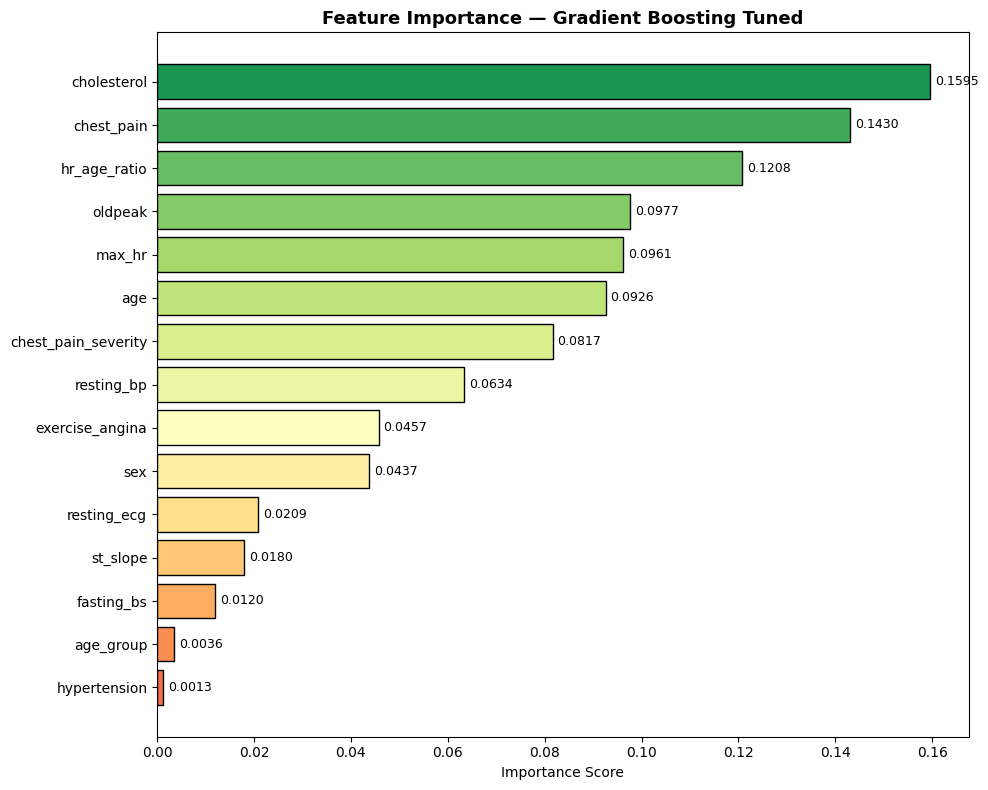

Top 5 Features:
cholesterol     0.159528
chest_pain      0.143036
hr_age_ratio    0.120809
oldpeak         0.097682
max_hr          0.096149
dtype: float64


In [22]:
feat_imp = pd.Series(tuned_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colors, edgecolor='black')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Gradient Boosting Tuned',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Features:")
print(feat_imp.sort_values(ascending=False).head(5))

In [23]:
best_model = tuned_model
best_name  = 'Gradient Boosting Tuned'

with open('best_heart_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('heart_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('heart_feature_list.pkl', 'wb') as f:
    pickle.dump(feature_list, f)

print("✅ best_heart_model.pkl   — saved")
print("✅ heart_scaler.pkl       — saved")
print("✅ heart_feature_list.pkl — saved")

# Verify
with open('best_heart_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_verify = loaded_model.predict(X_test)
print(f"\n✅ Verification passed")
print(f"   Accuracy : {round(accuracy_score(y_test, y_verify), 4)}")
print(f"   Recall   : {round(recall_score(y_test, y_verify), 4)}")

✅ best_heart_model.pkl   — saved
✅ heart_scaler.pkl       — saved
✅ heart_feature_list.pkl — saved

✅ Verification passed
   Accuracy : 0.8207
   Recall   : 0.8627


In [25]:
def preprocess_input(raw_input: dict) -> pd.DataFrame:
    """
    Input:
    -------
    age             : int
    sex             : 'Male' or 'Female'
    chest_pain      : 'typical angina' / 'atypical angina'
                      'non-anginal' / 'asymptomatic'
    resting_bp      : float  (mm Hg)
    cholesterol     : float  (mg/dl)
    fasting_bs      : True or False
    resting_ecg     : 'normal' / 'st-t abnormality' / 'lv hypertrophy'
    max_hr          : float
    exercise_angina : True or False
    oldpeak         : float
    st_slope        : 'upsloping' / 'flat' / 'downsloping'
    """
    df_p = pd.DataFrame([raw_input])

    df_p['sex'] = df_p['sex'].map({'Male': 1, 'Female': 0})

    df_p['chest_pain'] = df_p['chest_pain'].map({
        'typical angina'  : 1,
        'atypical angina' : 2,
        'non-anginal'     : 3,
        'asymptomatic'    : 4
    })

    df_p['fasting_bs'] = df_p['fasting_bs'].map(
        {True: 1, False: 0, 1: 1, 0: 0}
    )

    df_p['resting_ecg'] = df_p['resting_ecg'].map({
        'normal'           : 0,
        'st-t abnormality' : 1,
        'lv hypertrophy'   : 2
    })

    df_p['exercise_angina'] = df_p['exercise_angina'].map(
        {True: 1, False: 0, 1: 1, 0: 0}
    )

    df_p['st_slope'] = df_p['st_slope'].map({
        'upsloping'   : 1,
        'flat'        : 2,
        'downsloping' : 3
    })

    df_p['age_group'] = pd.cut(
        df_p['age'], bins=[0, 40, 50, 60, 100],
        labels=[0, 1, 2, 3]
    ).astype(int)

    df_p['hr_age_ratio'] = (df_p['max_hr'] / df_p['age']).round(2)
    df_p['hypertension'] = (df_p['resting_bp'] >= 140).astype(int)
    df_p['chest_pain_severity'] = df_p['chest_pain'].map(
        {1: 0, 2: 1, 3: 2, 4: 3}
    )

    return df_p[feature_list]


# Test
sample_input = {
    'age'             : 55,
    'sex'             : 'Male',
    'chest_pain'      : 'asymptomatic',
    'resting_bp'      : 145,
    'cholesterol'     : 250,
    'fasting_bs'      : False,
    'resting_ecg'     : 'lv hypertrophy',
    'max_hr'          : 130,
    'exercise_angina' : True,
    'oldpeak'         : 1.5,
    'st_slope'        : 'flat'
}

processed = preprocess_input(sample_input)
pred      = loaded_model.predict(processed)
prob      = loaded_model.predict_proba(processed)[0][1]

print(f"Prediction  : {'⚠️ Disease' if pred[0]==1 else '✅ No Disease'}")
print(f"Probability : {prob:.4f}  ({prob*100:.1f}%)")
print(f"Risk Level  : {'🔴 High' if prob > 0.7 else ('🟡 Medium' if prob > 0.4 else '🟢 Low')}")
print(f"\n✅ Pipeline works correctly")

Prediction  : ⚠️ Disease
Probability : 0.9972  (99.7%)
Risk Level  : 🔴 High

✅ Pipeline works correctly


In [26]:
print("=" * 55)
print("  HEART DISEASE PREDICTION — FINAL SUMMARY")
print("=" * 55)
print(f"""
  Dataset      : {df.shape[0]:,} records
  Features     : {len(feature_list)}
  Split        : 80% Train / 20% Test
  Balance      : {round(y.mean()*100,1)}% Disease /
                 {round((1-y.mean())*100,1)}% No Disease

  ── All Models ──────────────────────────────""")

for _, row in results_df.iterrows():
    print(f"     {row['Model']:<25}"
          f"Acc={row['Accuracy']}  "
          f"Recall={row['Recall']}  "
          f"AUC={row['ROC-AUC']}")

files.download('best_heart_model.pkl')
files.download('heart_scaler.pkl')
files.download('heart_feature_list.pkl')

print(f"""
  ── Best Model (Tuned) ──────────────────────
  🏆 Model     : Gradient Boosting Tuned
     Accuracy  : {round(accuracy_score(y_test, y_pred_t), 4)}
     Precision : {round(precision_score(y_test, y_pred_t), 4)}
     Recall    : {round(recall_score(y_test, y_pred_t), 4)}
     F1-Score  : {round(f1_score(y_test, y_pred_t), 4)}
     ROC-AUC   : {round(roc_auc_score(y_test, y_proba_t), 4)}


  ── Saved Files ──────────────────────────────
  ✅ best_heart_model.pkl
  ✅ heart_scaler.pkl
  ✅ heart_feature_list.pkl
""")
print("=" * 55)


  HEART DISEASE PREDICTION — FINAL SUMMARY

  Dataset      : 920 records
  Features     : 15
  Split        : 80% Train / 20% Test
  Balance      : 55.3% Disease /
                 44.7% No Disease

  ── All Models ──────────────────────────────
     Random Forest            Acc=0.8207  Recall=0.902  AUC=0.9061
     Gradient Boosting        Acc=0.8152  Recall=0.8627  AUC=0.8741
     Logistic Regression      Acc=0.7989  Recall=0.8431  AUC=0.8881


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  ── Best Model (Tuned) ──────────────────────
  🏆 Model     : Gradient Boosting Tuned
     Accuracy  : 0.8207
     Precision : 0.8224
     Recall    : 0.8627
     F1-Score  : 0.8421
     ROC-AUC   : 0.8803

      
  ── Saved Files ──────────────────────────────
  ✅ best_heart_model.pkl
  ✅ heart_scaler.pkl
  ✅ heart_feature_list.pkl

